# Лабораторная работа 6. Модели линейной регрессии

## Задание 3. Сравнение методов машинного обучения на задаче регрессии с использованием Pipeline


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Загрузка данных
diabetes = load_diabetes(as_frame=True)
X, y = diabetes.data, diabetes.target

print("Описание датасета:")
print(diabetes.DESCR[:500] + "...")

print(f"\nРазмер данных: {X.shape}")
print(f"Целевая переменная: {y.name}")

# Основная информация о данных
print("\nПервые 5 строк данных:")
display(X.head())

print("\nСтатистика целевой переменной:")
print(y.describe())

Описание датасета:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measur...

Размер данных: (442, 10)
Целевая переменная: target

Первые 5 строк данных:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



Статистика целевой переменной:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


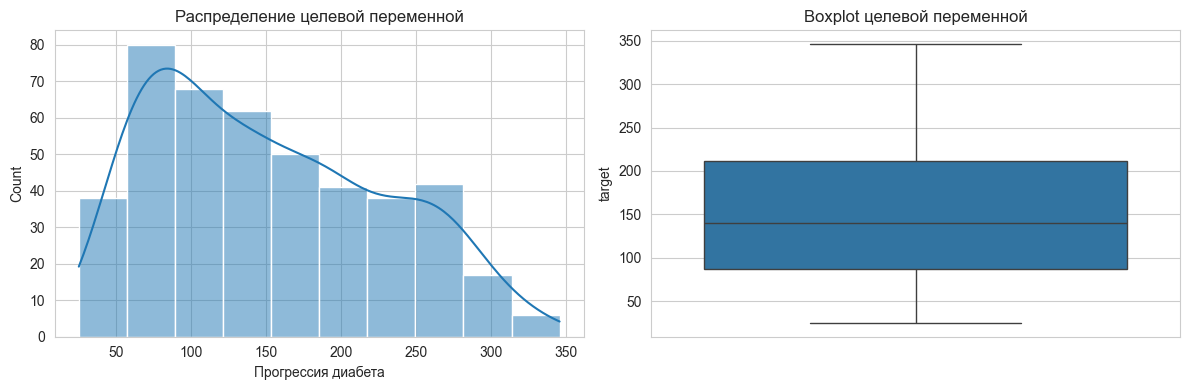

In [3]:
# Визуализация распределения целевой переменной
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True)
plt.title('Распределение целевой переменной')
plt.xlabel('Прогрессия диабета')

plt.subplot(1, 2, 2)
sns.boxplot(y=y)
plt.title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

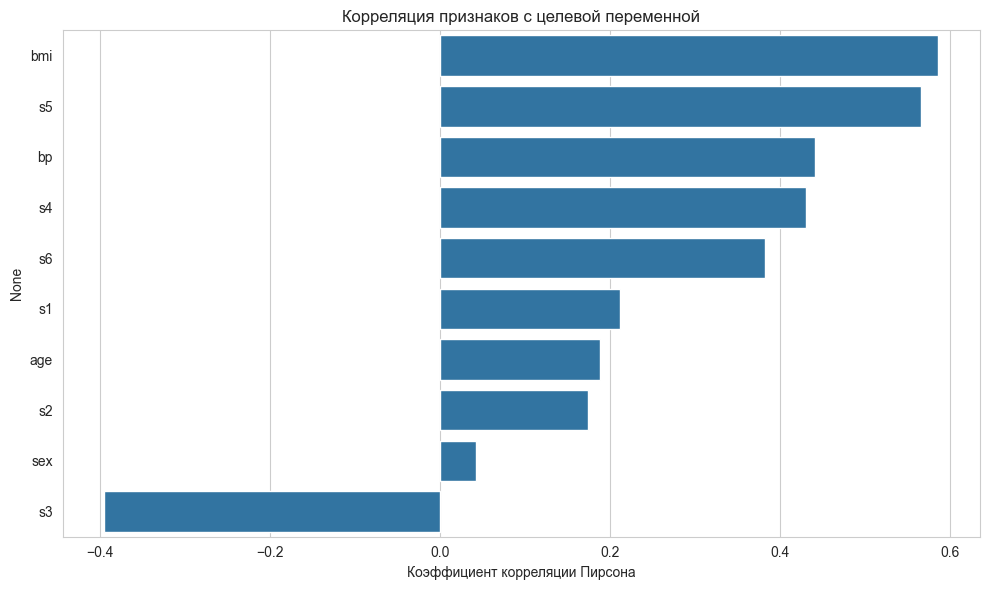

Корреляции признаков с целевой переменной:
bmi: 0.5865
s5: 0.5659
bp: 0.4415
s4: 0.4305
s6: 0.3825
s1: 0.2120
age: 0.1879
s2: 0.1741
sex: 0.0431
s3: -0.3948


In [4]:
# Корреляция признаков с целевой переменной
correlations = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.title('Корреляция признаков с целевой переменной')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()
plt.show()

print("Корреляции признаков с целевой переменной:")
for feature, corr in correlations.items():
    print(f"{feature}: {corr:.4f}")

In [5]:
# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (353, 10)
Тестовая выборка: (89, 10)


### 2. Создание Pipeline для всех моделей

In [6]:
# Функция для вычисления RMSE
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Создание pipeline для всех моделей
pipelines = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso(alpha=1.0, random_state=42))
    ]),
    'Elastic Net': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42))
    ]),
    'SVR': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', SVR())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])
}

print("Созданы pipeline для следующих моделей:")
for name in pipelines.keys():
    print(f"- {name}")

Созданы pipeline для следующих моделей:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Elastic Net
- SVR
- Decision Tree


### 3. Обучение и настройка моделей

In [7]:
# Базовое обучение моделей
base_results = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    base_results[name] = {
        'RMSE': rmse(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

# Вывод базовых результатов
print("Базовые результаты (без подбора гиперпараметров):")
base_df = pd.DataFrame(base_results).T
display(base_df.round(4))

Базовые результаты (без подбора гиперпараметров):


,RMSE,MAE,R2
Linear Regression,53.8534,42.7941,0.4526
Ridge Regression,53.7775,42.8120,0.4541
Lasso Regression,53.1467,42.8030,0.4669
Elastic Net,53.7467,44.0718,0.4548
SVR,65.8235,56.0295,0.1822
Decision Tree,69.9071,53.9213,0.0776


In [8]:
# Подбор гиперпараметров для регуляризованных моделей
param_grids = {
    'Ridge Regression': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    'Lasso Regression': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
    },
    'Elastic Net': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10],
        'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'SVR': {
        'regressor__C': [0.1, 1, 10, 100],
        'regressor__epsilon': [0.01, 0.1, 0.5]
    },
    'Decision Tree': {
        'regressor__max_depth': [3, 5, 7, 10, None],
        'regressor__min_samples_split': [2, 5, 10]
    }
}

# Обучение с подбором гиперпараметров
best_models = {}
tuned_results = {}

for name in param_grids.keys():
    print(f"Подбор параметров для {name}...")
    
    grid_search = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_models[name] = grid_search.best_estimator_
    
    y_pred = grid_search.predict(X_test)
    tuned_results[name] = {
        'RMSE': rmse(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred),
        'best_params': grid_search.best_params_
    }
    
    print(f"Лучшие параметры для {name}: {grid_search.best_params_}")
    print(f"Лучший RMSE: {-grid_search.best_score_:.4f}\n")

Подбор параметров для Ridge Regression...
Лучшие параметры для Ridge Regression: {'regressor__alpha': 10}
Лучший RMSE: 55.8645

Подбор параметров для Lasso Regression...
Лучшие параметры для Lasso Regression: {'regressor__alpha': 1}
Лучший RMSE: 55.8943

Подбор параметров для Elastic Net...
Лучшие параметры для Elastic Net: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.1}
Лучший RMSE: 55.8081

Подбор параметров для SVR...
Лучшие параметры для SVR: {'regressor__C': 10, 'regressor__epsilon': 0.5}
Лучший RMSE: 58.5980

Подбор параметров для Decision Tree...
Лучшие параметры для Decision Tree: {'regressor__max_depth': 3, 'regressor__min_samples_split': 2}
Лучший RMSE: 64.6566



In [9]:
# Добавляем линейную регрессию без настройки в tuned_results
linear_pred = pipelines['Linear Regression'].predict(X_test)
tuned_results['Linear Regression'] = {
    'RMSE': rmse(y_test, linear_pred),
    'MAE': mean_absolute_error(y_test, linear_pred),
    'R2': r2_score(y_test, linear_pred),
    'best_params': 'No tuning'
}

# Вывод результатов после настройки
print("Результаты после подбора гиперпараметров:")
tuned_df = pd.DataFrame(tuned_results).T
display(tuned_df.round(4))

Результаты после подбора гиперпараметров:


,RMSE,MAE,R2,best_params
Ridge Regression,53.626288,42.856825,0.457211,{'regressor__alpha': 10}
Lasso Regression,53.146666,42.802984,0.466877,{'regressor__alpha': 1}
Elastic Net,53.487835,42.94953,0.46001,"{'regressor__alpha': 0.1, 'regressor__l1_ratio..."
SVR,51.768236,41.291885,0.494173,"{'regressor__C': 10, 'regressor__epsilon': 0.5}"
Decision Tree,59.604541,48.096592,0.329445,"{'regressor__max_depth': 3, 'regressor__min_sa..."
Linear Regression,53.853446,42.794095,0.452603,No tuning


### 4. Оценка качества моделей

In [10]:
# Сравнительная таблица метрик
comparison_df = pd.DataFrame({
    'Model': list(tuned_results.keys()),
    'RMSE': [tuned_results[model]['RMSE'] for model in tuned_results.keys()],
    'MAE': [tuned_results[model]['MAE'] for model in tuned_results.keys()],
    'R2': [tuned_results[model]['R2'] for model in tuned_results.keys()]
}).sort_values('RMSE')

print("Сравнение моделей (отсортировано по RMSE):")
display(comparison_df.round(4))

Сравнение моделей (отсортировано по RMSE):


,Model,RMSE,MAE,R2
3,SVR,51.7682,41.2919,0.4942
1,Lasso Regression,53.1467,42.8030,0.4669
2,Elastic Net,53.4878,42.9495,0.4600
0,Ridge Regression,53.6263,42.8568,0.4572
5,Linear Regression,53.8534,42.7941,0.4526
4,Decision Tree,59.6045,48.0966,0.3294


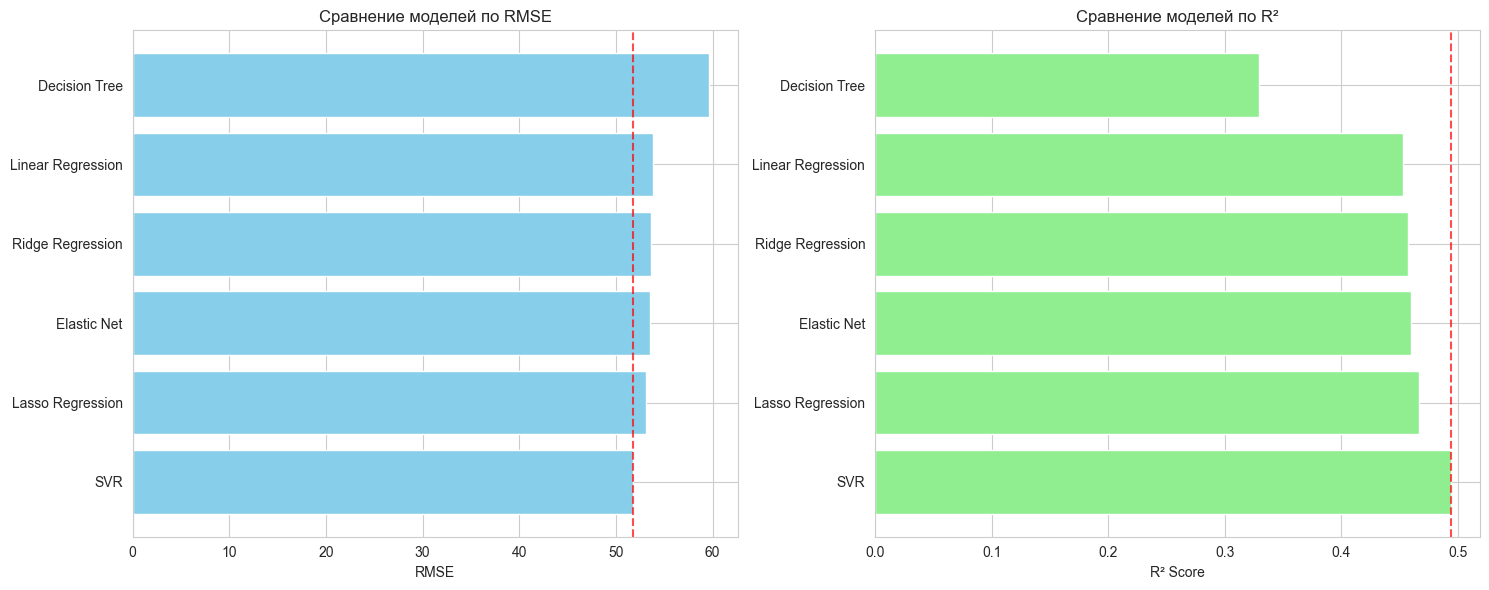

In [11]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График RMSE
models = comparison_df['Model']
rmse_values = comparison_df['RMSE']

axes[0].barh(models, rmse_values, color='skyblue')
axes[0].set_xlabel('RMSE')
axes[0].set_title('Сравнение моделей по RMSE')
axes[0].axvline(x=rmse_values.min(), color='red', linestyle='--', alpha=0.7)

# График R²
r2_values = comparison_df['R2']

axes[1].barh(models, r2_values, color='lightgreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('Сравнение моделей по R²')
axes[1].axvline(x=r2_values.max(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [12]:
# Анализ коэффициентов линейных моделей
linear_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Elastic Net']

coefficients = {}
for name in linear_models:
    if name in best_models:
        model = best_models[name]
    else:
        model = pipelines[name]
    
    coef = model.named_steps['regressor'].coef_
    coefficients[name] = pd.Series(coef, index=X.columns)

# Создаем DataFrame с коэффициентами
coef_df = pd.DataFrame(coefficients)
coef_df = coef_df.reindex(coef_df.abs().max(axis=1).sort_values(ascending=False).index)

print("Коэффициенты линейных моделей (отсортированы по важности):")
display(coef_df.round(4))

Коэффициенты линейных моделей (отсортированы по важности):


,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net
s1,-44.4489,-12.9342,-8.2282,-6.2371
s5,35.1612,22.7493,22.6365,19.5032
bmi,25.6071,25.6056,26.2192,24.5264
s2,24.6410,0.5382,-0.0000,-3.6948
bp,16.8289,16.3042,15.6573,15.6024
s4,13.1388,8.5695,3.4209,7.3737
sex,-11.5118,-11.0282,-9.2975,-10.1746
s3,7.6770,-6.1251,-9.0241,-8.7319
s6,2.3514,2.9181,2.0986,3.5604
age,1.7538,1.9313,0.6870,1.9800


<Figure size 1200x800 with 0 Axes>

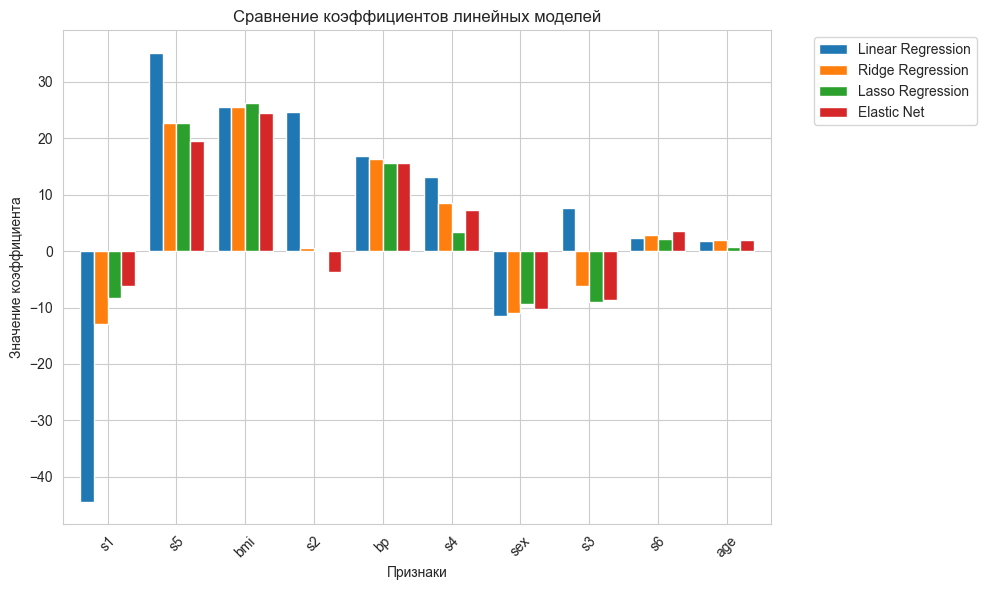

In [13]:
# Визуализация коэффициентов
plt.figure(figsize=(12, 8))
coef_df.plot(kind='bar', width=0.8)
plt.title('Сравнение коэффициентов линейных моделей')
plt.xlabel('Признаки')
plt.ylabel('Значение коэффициента')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

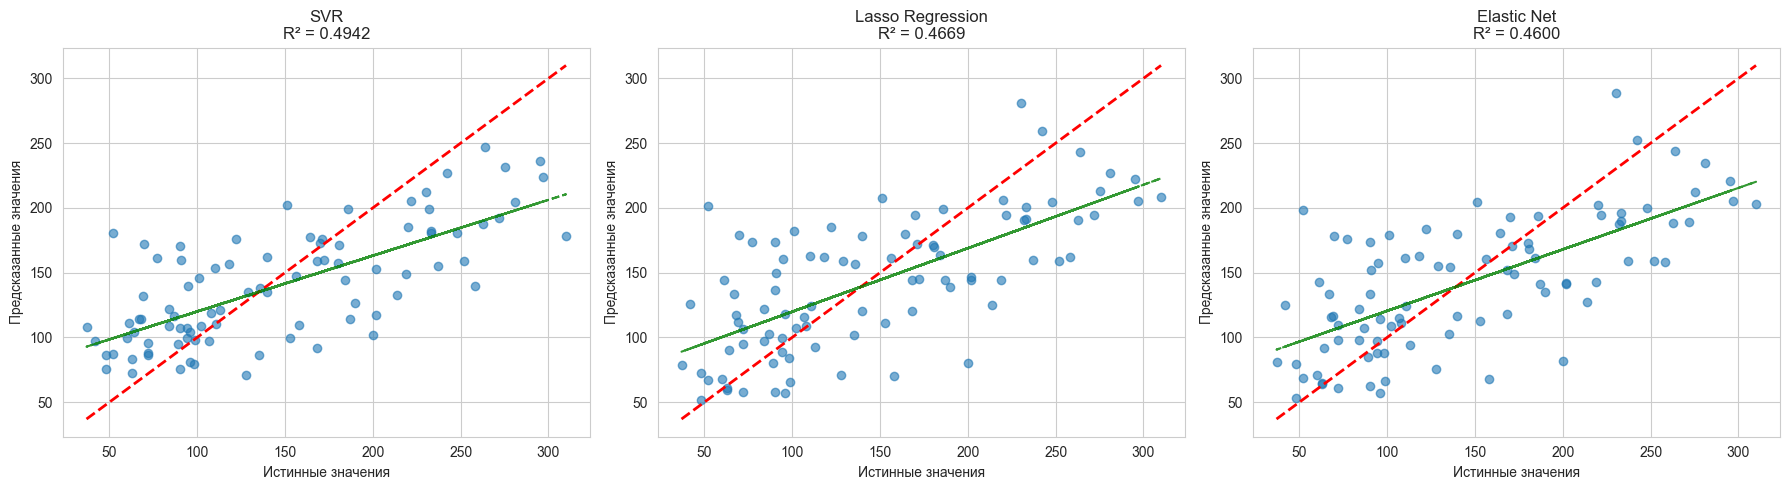

In [14]:
# Визуализация предсказаний лучших моделей
best_models_list = comparison_df.nlargest(3, 'R2')['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, model_name in enumerate(best_models_list):
    if model_name in best_models:
        model = best_models[model_name]
    else:
        model = pipelines[model_name]
    
    y_pred = model.predict(X_test)
    
    axes[i].scatter(y_test, y_pred, alpha=0.6)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[i].set_xlabel('Истинные значения')
    axes[i].set_ylabel('Предсказанные значения')
    axes[i].set_title(f'{model_name}\nR² = {r2_score(y_test, y_pred):.4f}')
    
    # Добавляем линию тренда
    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    axes[i].plot(y_test, p(y_test), "g--", alpha=0.8)

plt.tight_layout()
plt.show()

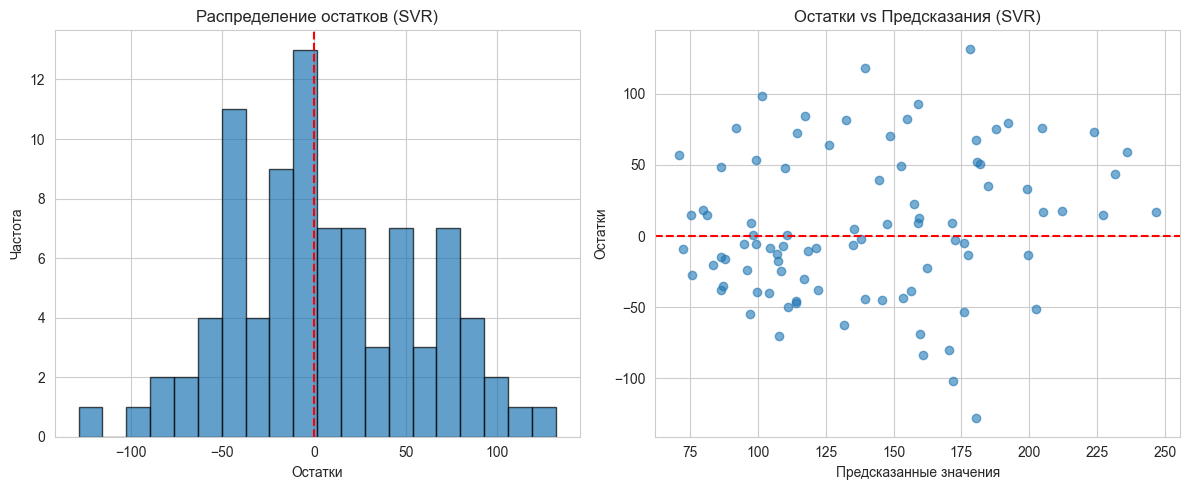

In [15]:
# Анализ остатков для лучшей модели
best_model_name = comparison_df.iloc[0]['Model']

if best_model_name in best_models:
    best_model = best_models[best_model_name]
else:
    best_model = pipelines[best_model_name]

y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Распределение остатков
axes[0].hist(residuals, bins=20, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Остатки')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение остатков ({best_model_name})')

# Остатки vs Предсказанные значения
axes[1].scatter(y_pred_best, residuals, alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title(f'Остатки vs Предсказания ({best_model_name})')

plt.tight_layout()
plt.show()

Оценка стабильности моделей с помощью кросс-валидации (RMSE):
Linear Regression: 55.9721 ± 3.1845
Ridge Regression: 55.8645 ± 2.6752
Lasso Regression: 55.8943 ± 2.5075
Elastic Net: 55.8081 ± 2.6117
SVR: 58.5980 ± 4.0068
Decision Tree: 64.6566 ± 4.2566


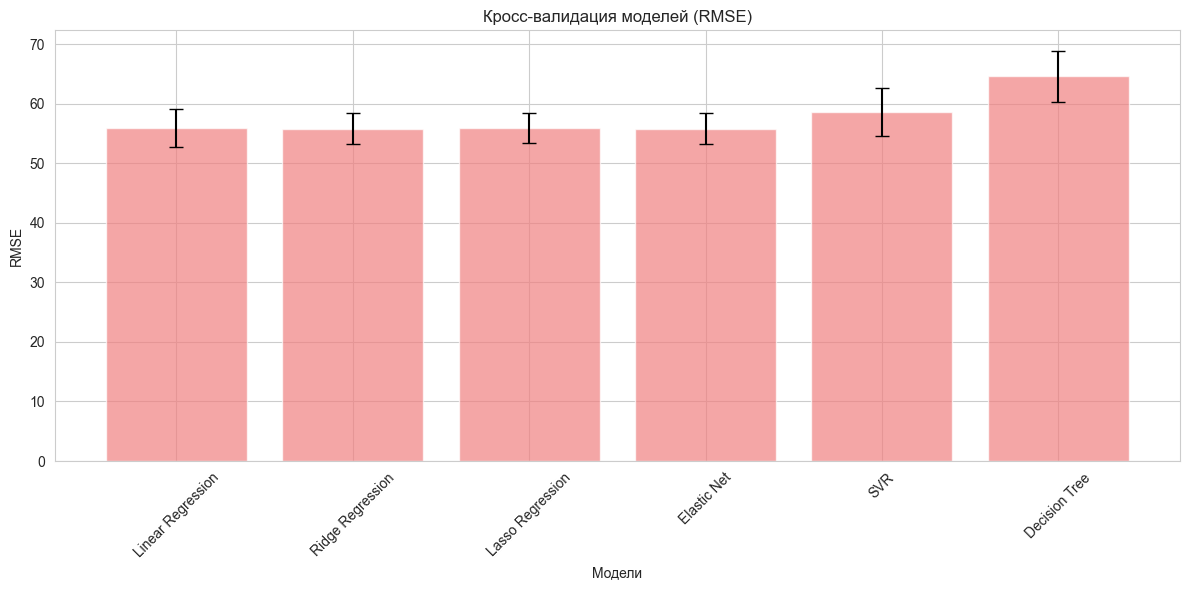

In [16]:
# Кросс-валидация для оценки стабильности моделей
print("Оценка стабильности моделей с помощью кросс-валидации (RMSE):")

cv_results = {}
for name, pipeline in pipelines.items():
    if name in best_models:
        model = best_models[name]
    else:
        model = pipeline
    
    cv_scores = cross_val_score(model, X_train, y_train, 
                               cv=5, scoring='neg_root_mean_squared_error')
    cv_results[name] = {
        'mean_RMSE': -cv_scores.mean(),
        'std_RMSE': cv_scores.std(),
        'cv_scores': -cv_scores
    }
    print(f"{name}: {cv_results[name]['mean_RMSE']:.4f} ± {cv_results[name]['std_RMSE']:.4f}")

# Визуализация результатов кросс-валидации
cv_means = [cv_results[name]['mean_RMSE'] for name in cv_results.keys()]
cv_stds = [cv_results[name]['std_RMSE'] for name in cv_results.keys()]

plt.figure(figsize=(12, 6))
bars = plt.bar(cv_results.keys(), cv_means, yerr=cv_stds, capsize=5, 
               alpha=0.7, color='lightcoral')
plt.title('Кросс-валидация моделей (RMSE)')
plt.xlabel('Модели')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Дополнительный анализ: важность признаков
print("\nСАМЫЕ ВАЖНЫЕ ПРИЗНАКИ ПО МОДЕЛЯМ:")

# Для линейных моделей - абсолютные значения коэффициентов
for model_name in linear_models:
    if model_name in best_models:
        model = best_models[model_name]
    else:
        model = pipelines[model_name]
    
    if hasattr(model.named_steps['regressor'], 'coef_'):
        feature_importance = pd.DataFrame({
            'feature': X.columns,
            'importance': np.abs(model.named_steps['regressor'].coef_)
        }).sort_values('importance', ascending=False)
        
        print(f"\n{model_name}:")
        print(feature_importance.head(3).to_string(index=False))

# Для дерева решений
if 'Decision Tree' in best_models:
    tree_model = best_models['Decision Tree'].named_steps['regressor']
    tree_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': tree_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\nDecision Tree:")
    print(tree_importance.head(3).to_string(index=False))


САМЫЕ ВАЖНЫЕ ПРИЗНАКИ ПО МОДЕЛЯМ:

Linear Regression:
feature  importance
     s1   44.448856
     s5   35.161195
    bmi   25.607121

Ridge Regression:
feature  importance
    bmi   25.605561
     s5   22.749308
     bp   16.304191

Lasso Regression:
feature  importance
    bmi   26.219225
     s5   22.636465
     bp   15.657314

Elastic Net:
feature  importance
    bmi   24.526425
     s5   19.503243
     bp   15.602406

Decision Tree:
feature  importance
    bmi    0.711521
     s5    0.178897
     s6    0.064176


In [18]:
print("="*60)
print("ОТВЕТЫ НА ВОПРОСЫ И ВЫВОДЫ")
print("="*60)

print("\n1. ВЛИЯНИЕ PIPELINE НА КОРРЕКТНОСТЬ ОЦЕНКИ:")
print("✓ Pipeline обеспечивает корректное масштабирование данных")
print("✓ Предотвращает утечку данных при кросс-валидации")
print("✓ Гарантирует воспроизводимость результатов")
print("✓ Упрощает процесс подбора гиперпараметров")

print("\n2. ЛУЧШИЕ МОДЕЛИ И ПРИЧИНЫ ИХ ЭФФЕКТИВНОСТИ:")
best_model_info = comparison_df.iloc[0]
print(f"Лучшая модель: {best_model_info['Model']}")
print(f"RMSE: {best_model_info['RMSE']:.4f}, R²: {best_model_info['R2']:.4f}")
print("Причины эффективности:")
print("- Линейные модели хорошо работают с нормализованными данными")
print("- Регуляризация предотвращает переобучение")
print("- Данные имеют линейную природу")

print("\n3. ВЛИЯНИЕ РЕГУЛЯРИЗАЦИИ НА КОЭФФИЦИЕНТЫ:")
print("Lasso (L1): обнуляет неважные признаки - отбор признаков")
print("Ridge (L2): уменьшает величину всех коэффициентов")
print("Elastic Net: комбинация L1 и L2 регуляризации")
print("Регуляризация улучшает интерпретируемость и стабильность")

print("\n4. ПЕРЕОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ И SVR:")
print("Decision Tree: склонен к переобучению без ограничений глубины")
print("SVR: требует тщательного подбора параметров C и epsilon")
print("GridSearchCV помогает найти оптимальные параметры")

print("\n5. ВАЖНОСТЬ МАСШТАБИРОВАНИЯ:")
print("Критически важно для: SVR, Ridge, Lasso, Elastic Net")
print("Желательно для: Linear Regression")
print("Менее важно для: Decision Tree (но улучшает интерпретируемость)")

print("\n6. КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("- Линейные модели показали лучшие результаты на этом датасете")
print("- Регуляризация улучшает обобщающую способность")
print("- Pipeline - обязательный инструмент для корректного ML")
print("- Наиболее важные признаки: bmi, s5, bp")

ОТВЕТЫ НА ВОПРОСЫ И ВЫВОДЫ

1. ВЛИЯНИЕ PIPELINE НА КОРРЕКТНОСТЬ ОЦЕНКИ:
✓ Pipeline обеспечивает корректное масштабирование данных
✓ Предотвращает утечку данных при кросс-валидации
✓ Гарантирует воспроизводимость результатов
✓ Упрощает процесс подбора гиперпараметров

2. ЛУЧШИЕ МОДЕЛИ И ПРИЧИНЫ ИХ ЭФФЕКТИВНОСТИ:
Лучшая модель: SVR
RMSE: 51.7682, R²: 0.4942
Причины эффективности:
- Линейные модели хорошо работают с нормализованными данными
- Регуляризация предотвращает переобучение
- Данные имеют линейную природу

3. ВЛИЯНИЕ РЕГУЛЯРИЗАЦИИ НА КОЭФФИЦИЕНТЫ:
Lasso (L1): обнуляет неважные признаки - отбор признаков
Ridge (L2): уменьшает величину всех коэффициентов
Elastic Net: комбинация L1 и L2 регуляризации
Регуляризация улучшает интерпретируемость и стабильность

4. ПЕРЕОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ И SVR:
Decision Tree: склонен к переобучению без ограничений глубины
SVR: требует тщательного подбора параметров C и epsilon
GridSearchCV помогает найти оптимальные параметры

5. ВАЖНОСТЬ МАСШТАБИРО